## TP2 -- Florian ANDRE (ING4 Majeure Cybersécurité, groupe 1)

L'objectif de ce TP2 est de concevoir un modèle Intelligent susceptible d’améliorer la prédiction des commandes en retard « Backorder Prediction ». 
Il s’agit d’un problème de classification.

Une commande en retard se produit lorsqu'un client potentiel tente de commander
un produit, mais que sa commande ne peut être exécutée immédiatement parce que
l’entreprise ne dispose pas du produit en question en stock. Le client est informé que le
produit est en rupture de stock dans cette situation. Ce dernier a la possibilité de
poursuivre la transaction, d'effectuer un achat, puis d'attendre le nouveau produit.

Il peut également choisir de refuser la commande et de ne pas l'exécuter, ou de la
poursuivre mais de l'annuler s'il trouve une solution plus rapide.

Le jeu de données comporte 2 ensembles : 1 ensemble d'entraînement dit Training et 1 ensemble de test dit Test

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Prétraitement des données

Importation des fichiers csv TR (training) et TS (test)

In [2]:
TR = pd.read_csv("Training_BOP.csv")
TS = pd.read_csv("Testing_BOP.csv")


/tmp/ipykernel_96958/1814343395.py:1: DtypeWarning: Columns (0: sku) have mixed types. Specify dtype option on import or set low_memory=False.
  TR = pd.read_csv("Training_BOP.csv")
/tmp/ipykernel_96958/1814343395.py:2: DtypeWarning: Columns (0: sku) have mixed types. Specify dtype option on import or set low_memory=False.
  TS = pd.read_csv("Testing_BOP.csv")


1. Affichage des 5 premières lignes

In [3]:
print("=== TRAIN ===")
display(TR.head())

print("\n=== TEST ===")
display(TS.head())

=== TRAIN ===


,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,No,No,No,Yes,No,No
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.99,0.99,0.0,No,No,No,Yes,No,No
2,1043696,2.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.10,0.13,0.0,No,No,No,Yes,No,No
4,1044048,8.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No



=== TEST ===


,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,3285085,62.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
1,3285131,9.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,No,No,Yes,No,No,No
2,3285358,17.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.92,0.95,0.0,No,No,No,Yes,No,No
3,3285517,9.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.78,0.75,0.0,No,No,Yes,Yes,No,No
4,3285608,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.54,0.71,0.0,No,No,No,Yes,No,No


2. Dimensions

In [4]:
dim_TR = TR.shape
dim_TS = TS.shape

print(f"la dimension de TR est : {dim_TR}")
print(f"la dimension de TS est : {dim_TS}")

la dimension de TR est : (1687861, 23)
la dimension de TS est : (242076, 23)


3. Types des variables

In [5]:
print("=== Types des variables de TR ===")
TR.info()

=== Types des variables de TR ===
<class 'pandas.DataFrame'>
RangeIndex: 1687861 entries, 0 to 1687860
Data columns (total 23 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   sku                1687861 non-null  object 
 1   national_inv       1687860 non-null  float64
 2   lead_time          1586967 non-null  float64
 3   in_transit_qty     1687860 non-null  float64
 4   forecast_3_month   1687860 non-null  float64
 5   forecast_6_month   1687860 non-null  float64
 6   forecast_9_month   1687860 non-null  float64
 7   sales_1_month      1687860 non-null  float64
 8   sales_3_month      1687860 non-null  float64
 9   sales_6_month      1687860 non-null  float64
 10  sales_9_month      1687860 non-null  float64
 11  min_bank           1687860 non-null  float64
 12  potential_issue    1687860 non-null  str    
 13  pieces_past_due    1687860 non-null  float64
 14  perf_6_month_avg   1687860 non-null  float64
 15  perf_12_m

4. Valeurs manquantes

In [6]:
missing_TR = TR.isnull().sum()
missing_TS = TS.isnull().sum()

print("=== Nombre des valeurs manquantes dans TR par champ ===")
display(missing_TR[missing_TR > 0])

print("=== Nombre des valeurs manquantes dans TS par champ ===")
display(missing_TS[missing_TS > 0])

=== Nombre des valeurs manquantes dans TR par champ ===


national_inv              1
lead_time            100894
in_transit_qty            1
forecast_3_month          1
forecast_6_month          1
forecast_9_month          1
sales_1_month             1
sales_3_month             1
sales_6_month             1
sales_9_month             1
min_bank                  1
potential_issue           1
pieces_past_due           1
perf_6_month_avg          1
perf_12_month_avg         1
local_bo_qty              1
deck_risk                 1
oe_constraint             1
ppap_risk                 1
stop_auto_buy             1
rev_stop                  1
went_on_backorder         1
dtype: int64

=== Nombre des valeurs manquantes dans TS par champ ===


national_inv             1
lead_time            14725
in_transit_qty           1
forecast_3_month         1
forecast_6_month         1
forecast_9_month         1
sales_1_month            1
sales_3_month            1
sales_6_month            1
sales_9_month            1
min_bank                 1
potential_issue          1
pieces_past_due          1
perf_6_month_avg         1
perf_12_month_avg        1
local_bo_qty             1
deck_risk                1
oe_constraint            1
ppap_risk                1
stop_auto_buy            1
rev_stop                 1
went_on_backorder        1
dtype: int64

Calcul du pourcentage de valeurs manquantes

In [7]:
missing_TR_pct = (TR.isnull().sum() / len(TR)) * 100
missing_TS_pct = (TS.isnull().sum() / len(TS)) * 100

In [8]:
missing_TR_table = pd.DataFrame({
    "Nombre manquant": missing_TR,
    "Pourcentage (%)": missing_TR_pct
})

missing_TS_table = pd.DataFrame({
    "Nombre manquant": missing_TS,
    "Pourcentage (%)": missing_TS_pct
})

print("=== Valeurs manquantes TR ===")
display(missing_TR_table[missing_TR_table["Nombre manquant"] > 0])

print("=== Valeurs manquantes TS ===")
display(missing_TS_table[missing_TS_table["Nombre manquant"] > 0])

=== Valeurs manquantes TR ===


,Nombre manquant,Pourcentage (%)
national_inv,1,0.000059
lead_time,100894,5.977625
in_transit_qty,1,0.000059
forecast_3_month,1,0.000059
forecast_6_month,1,0.000059
forecast_9_month,1,0.000059
sales_1_month,1,0.000059
sales_3_month,1,0.000059
sales_6_month,1,0.000059
sales_9_month,1,0.000059


=== Valeurs manquantes TS ===


,Nombre manquant,Pourcentage (%)
national_inv,1,0.000413
lead_time,14725,6.082800
in_transit_qty,1,0.000413
forecast_3_month,1,0.000413
forecast_6_month,1,0.000413
forecast_9_month,1,0.000413
sales_1_month,1,0.000413
sales_3_month,1,0.000413
sales_6_month,1,0.000413
sales_9_month,1,0.000413


Interprétation des résultats : 

5. Statistiques descriptives de TR et de TS

In [9]:
##Variables numériques
print("=== Statistiques descriptives de TR ===")
display(TR.describe().T)

print("=== Statistiques descriptives de TS ===")
display(TS.describe().T)

=== Statistiques descriptives de TR ===


,count,mean,std,min,25%,50%,75%,max
national_inv,1687860.0,496.111782,29615.233831,-27256.0,4.00,15.00,80.00,12334404.0
lead_time,1586967.0,7.872267,7.056024,0.0,4.00,8.00,9.00,52.0
in_transit_qty,1687860.0,44.052022,1342.741731,0.0,0.00,0.00,0.00,489408.0
forecast_3_month,1687860.0,178.119284,5026.553102,0.0,0.00,0.00,4.00,1427612.0
forecast_6_month,1687860.0,344.986664,9795.151861,0.0,0.00,0.00,12.00,2461360.0
forecast_9_month,1687860.0,506.364431,14378.923562,0.0,0.00,0.00,20.00,3777304.0
sales_1_month,1687860.0,55.926069,1928.195879,0.0,0.00,0.00,4.00,741774.0
sales_3_month,1687860.0,175.025930,5192.377625,0.0,0.00,1.00,15.00,1105478.0
sales_6_month,1687860.0,341.728839,9613.167104,0.0,0.00,2.00,31.00,2146625.0
sales_9_month,1687860.0,525.269701,14838.613523,0.0,0.00,4.00,47.00,3205172.0


=== Statistiques descriptives de TS ===


,count,mean,std,min,25%,50%,75%,max
national_inv,242075.0,499.751028,29280.390793,-25414.0,4.00,15.00,81.00,12145792.0
lead_time,227351.0,7.923018,7.041410,0.0,4.00,8.00,9.00,52.0
in_transit_qty,242075.0,36.178213,898.673127,0.0,0.00,0.00,0.00,265272.0
forecast_3_month,242075.0,181.472345,5648.874620,0.0,0.00,0.00,4.00,1510592.0
forecast_6_month,242075.0,348.807304,10081.797119,0.0,0.00,0.00,12.00,2157024.0
forecast_9_month,242075.0,508.296301,14109.723787,0.0,0.00,0.00,20.00,3162260.0
sales_1_month,242075.0,51.478195,1544.678350,0.0,0.00,0.00,4.00,349620.0
sales_3_month,242075.0,172.139316,5164.243624,0.0,0.00,1.00,14.00,1099852.0
sales_6_month,242075.0,340.425414,9386.523492,0.0,0.00,2.00,30.00,2103389.0
sales_9_month,242075.0,511.775446,13976.702192,0.0,0.00,4.00,46.00,3195211.0


In [10]:
# Variables catégorielles
print("Types des variables :")
display(TR.dtypes)

## Affichage statistiques variables catégorielles

cat_cols = TR.select_dtypes(include=["object", "category"]).columns

print("Variables catégorielles :")
print(list(cat_cols))

print("\n=== Statistiques des variables catégorielles de TR ===")
display(TR[cat_cols].describe().T)

print("\n=== Statistiques des variables catégorielles de TS ===")
display(TS[cat_cols].describe().T)

Types des variables :


sku                   object
national_inv         float64
lead_time            float64
in_transit_qty       float64
forecast_3_month     float64
forecast_6_month     float64
forecast_9_month     float64
sales_1_month        float64
sales_3_month        float64
sales_6_month        float64
sales_9_month        float64
min_bank             float64
potential_issue          str
pieces_past_due      float64
perf_6_month_avg     float64
perf_12_month_avg    float64
local_bo_qty         float64
deck_risk                str
oe_constraint            str
ppap_risk                str
stop_auto_buy            str
rev_stop                 str
went_on_backorder        str
dtype: object

Variables catégorielles :
['sku', 'potential_issue', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop', 'went_on_backorder']

=== Statistiques des variables catégorielles de TR ===


/tmp/ipykernel_96958/1411924203.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = TR.select_dtypes(include=["object", "category"]).columns


,count,unique,top,freq
sku,1687861,1687861,1026827,1
potential_issue,1687860,2,No,1686953
deck_risk,1687860,2,No,1300377
oe_constraint,1687860,2,No,1687615
ppap_risk,1687860,2,No,1484026
stop_auto_buy,1687860,2,Yes,1626774
rev_stop,1687860,2,No,1687129
went_on_backorder,1687860,2,No,1676567



=== Statistiques des variables catégorielles de TS ===


,count,unique,top,freq
sku,242076,242076,3285085,1
potential_issue,242075,2,No,241993
deck_risk,242075,2,No,194105
oe_constraint,242075,2,No,242028
ppap_risk,242075,2,No,213357
stop_auto_buy,242075,2,Yes,232617
rev_stop,242075,2,No,241967
went_on_backorder,242075,2,No,239387


In [11]:
# Vérification des variables uniques 
for col in TR.columns:
    print(f"{col} : {TR[col].nunique()} valeurs uniques")

for col in TR.columns:
    if TR[col].nunique() <= 10:
        print(f"\n--- {col} ---")
        print(TR[col].value_counts(dropna=False))
display(TR.dtypes)

sku : 1687861 valeurs uniques
national_inv : 14969 valeurs uniques
lead_time : 32 valeurs uniques
in_transit_qty : 5230 valeurs uniques
forecast_3_month : 7825 valeurs uniques
forecast_6_month : 11114 valeurs uniques
forecast_9_month : 13662 valeurs uniques
sales_1_month : 5764 valeurs uniques
sales_3_month : 10495 valeurs uniques
sales_6_month : 14818 valeurs uniques
sales_9_month : 18341 valeurs uniques
min_bank : 5568 valeurs uniques
potential_issue : 2 valeurs uniques
pieces_past_due : 826 valeurs uniques
perf_6_month_avg : 102 valeurs uniques
perf_12_month_avg : 102 valeurs uniques
local_bo_qty : 654 valeurs uniques
deck_risk : 2 valeurs uniques
oe_constraint : 2 valeurs uniques
ppap_risk : 2 valeurs uniques
stop_auto_buy : 2 valeurs uniques
rev_stop : 2 valeurs uniques
went_on_backorder : 2 valeurs uniques

--- potential_issue ---
potential_issue
No     1686953
Yes        907
NaN          1
Name: count, dtype: int64

--- deck_risk ---
deck_risk
No     1300377
Yes     387483
NaN  

sku                   object
national_inv         float64
lead_time            float64
in_transit_qty       float64
forecast_3_month     float64
forecast_6_month     float64
forecast_9_month     float64
sales_1_month        float64
sales_3_month        float64
sales_6_month        float64
sales_9_month        float64
min_bank             float64
potential_issue          str
pieces_past_due      float64
perf_6_month_avg     float64
perf_12_month_avg    float64
local_bo_qty         float64
deck_risk                str
oe_constraint            str
ppap_risk                str
stop_auto_buy            str
rev_stop                 str
went_on_backorder        str
dtype: object

Il faut supprimer les lignes vides avant le traitement des valeurs manquantes

In [12]:
empty_rows_TR = TR.isna().all(axis=1).sum()
empty_rows_TS = TS.isna().all(axis=1).sum()

print("Lignes complètement vides dans TR :", empty_rows_TR)
print("Lignes complètement vides dans TS :", empty_rows_TS)

print("SKU manquants TR :", TR["sku"].isna().sum())
print("SKU manquants TS :", TS["sku"].isna().sum())

display(TR[TR["sku"].isna()].head(10))

missing_per_row_TR = TR.isna().sum(axis=1)
missing_per_row_TS = TS.isna().sum(axis=1)

print("=== TR ===")
print(missing_per_row_TR.value_counts().sort_index())

print("\n=== TS ===")
print(missing_per_row_TS.value_counts().sort_index())

print("Nombre total de cellules manquantes TR :", TR.isna().sum().sum())
print("Nombre total de cellules manquantes TS :", TS.isna().sum().sum())

display(
    TR.isna().sum()
    .sort_values(ascending=False)
    .to_frame("Nombre de valeurs manquantes")
)

Lignes complètement vides dans TR : 0
Lignes complètement vides dans TS : 0
SKU manquants TR : 0
SKU manquants TS : 0


,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder


=== TR ===
0     1586967
1      100893
22          1
Name: count, dtype: int64

=== TS ===
0     227351
1      14724
22         1
Name: count, dtype: int64
Nombre total de cellules manquantes TR : 100915
Nombre total de cellules manquantes TS : 14746


,Nombre de valeurs manquantes
lead_time,100894
national_inv,1
in_transit_qty,1
forecast_6_month,1
forecast_3_month,1
forecast_9_month,1
sales_1_month,1
perf_12_month_avg,1
sales_3_month,1
sales_6_month,1


6. Traitement des valeurs manquantes

Comme trouvé dans le tableau des valeurs manquantes, on a environ 6% de valeurs manquantes pour la variable lead_time, contre 1 seule par variable pour les autres. La suppression n'est pas envisageable (on perdrait 100 000 enregistrements), et par conséquent, il faut imputer les valeurs manquantes. 

Comme lead_time est une variable quantitative et que les valeurs peuvent être asymétriques, la médiane sur TR est un choix raisonnable.
Pour les variables binaires, le mode est plus adapté. 

In [13]:
lead_time_median = TR["lead_time"].median()

print("Médiane de lead_time :", lead_time_median)

Médiane de lead_time : 8.0


Et on remplace les valeurs manquantes comme mentionné précédemment

In [14]:
# Colonnes numériques
num_cols = TR.select_dtypes(include=[np.number]).columns

# Colonnes catégorielles
cat_cols = TR.select_dtypes(include=["object", "category"]).columns

print("Variables numériques :")
print(list(num_cols))

print("\nVariables catégorielles :")
print(list(cat_cols))

Variables numériques :
['national_inv', 'lead_time', 'in_transit_qty', 'forecast_3_month', 'forecast_6_month', 'forecast_9_month', 'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month', 'min_bank', 'pieces_past_due', 'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty']

Variables catégorielles :
['sku', 'potential_issue', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop', 'went_on_backorder']


/tmp/ipykernel_96958/2033749811.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = TR.select_dtypes(include=["object", "category"]).columns


In [15]:
# Imputation des variables numériques par la médiane
for col in num_cols:
    if TR[col].isnull().sum() > 0:
        median = TR[col].median()
        TR[col] = TR[col].fillna(median)
        TS[col] = TS[col].fillna(median)

# Imputation des variables catégorielles par le mode
for col in cat_cols:
    if TR[col].isnull().sum() > 0:
        mode = TR[col].mode()[0]
        TR[col] = TR[col].fillna(mode)
        TS[col] = TS[col].fillna(mode)

## Sélection des variables pertinentes:

7. Corrélation entre les variables avec le test de khi-deux

Nous allons d'abord mesurer la corrélation entre les différentes variables du dataset. nous allons utiliser une liste pour définir les champs de données quantitatives, calculer la matrice de corrélation afin de déterminer les variables ayant la corrélation la plus élevée et identifier d'éventuelles redondances

In [16]:
quantitative = [
    "national_inv",
    "lead_time",
    "in_transit_qty",
    "forecast_3_month",
    "forecast_6_month",
    "forecast_9_month",
    "sales_1_month",
    "sales_3_month",
    "sales_6_month",
    "sales_9_month",
    "min_bank",
    "pieces_past_due",
    "perf_6_month_avg",
    "perf_12_month_avg",
    "local_bo_qty"
]

In [17]:
corr_matrix = TR[quantitative].corr()

display(corr_matrix)

,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty
national_inv,1.000000,0.003321,0.098238,0.078199,0.079744,0.078948,0.147449,0.192605,0.225067,0.239613,0.399969,0.030677,-0.013544,-0.010732,0.014887
lead_time,0.003321,1.000000,-0.006863,-0.008045,-0.008548,-0.008773,-0.005618,-0.006769,-0.007117,-0.007261,-0.007094,-0.001510,-0.052305,-0.049527,-0.001259
in_transit_qty,0.098238,-0.006863,1.000000,0.662648,0.687768,0.679152,0.619270,0.698417,0.689908,0.659372,0.749974,0.167460,0.003282,0.004292,0.066612
forecast_3_month,0.078199,-0.008045,0.662648,1.000000,0.990490,0.977337,0.684494,0.781178,0.835585,0.825539,0.725042,0.361214,0.008445,0.008694,0.039419
forecast_6_month,0.079744,-0.008548,0.687768,0.990490,1.000000,0.994945,0.701770,0.808755,0.868099,0.858253,0.738553,0.363147,0.008343,0.008499,0.039724
forecast_9_month,0.078948,-0.008773,0.679152,0.977337,0.994945,1.000000,0.716367,0.829911,0.891884,0.881894,0.735891,0.366001,0.008306,0.008421,0.039732
sales_1_month,0.147449,-0.005618,0.619270,0.684494,0.701770,0.716367,1.000000,0.918548,0.867479,0.815959,0.756137,0.249526,0.001163,0.002370,0.066188
sales_3_month,0.192605,-0.006769,0.698417,0.781178,0.808755,0.829911,0.918548,1.000000,0.975594,0.929491,0.856017,0.304565,0.001488,0.002837,0.071030
sales_6_month,0.225067,-0.007117,0.689908,0.835585,0.868099,0.891884,0.867479,0.975594,1.000000,0.971833,0.837110,0.323552,0.002898,0.004221,0.057765
sales_9_month,0.239613,-0.007261,0.659372,0.825539,0.858253,0.881894,0.815959,0.929491,0.971833,1.000000,0.800890,0.317692,0.003438,0.004749,0.048880


In [18]:
high_corr = []

for i in range(len(quantitative)):
    for j in range(i):
        corr = corr_matrix.iloc[i, j]

        if abs(corr) > 0.90:
            high_corr.append([
                quantitative[i],
                quantitative[j],
                corr
            ])

high_corr_df = pd.DataFrame(
    high_corr,
    columns=["Variable 1", "Variable 2", "Corrélation"]
)

display(high_corr_df)

,Variable 1,Variable 2,Corrélation
0,forecast_6_month,forecast_3_month,0.990490
1,forecast_9_month,forecast_3_month,0.977337
2,forecast_9_month,forecast_6_month,0.994945
3,sales_3_month,sales_1_month,0.918548
4,sales_6_month,sales_3_month,0.975594
5,sales_9_month,sales_3_month,0.929491
6,sales_9_month,sales_6_month,0.971833
7,perf_12_month_avg,perf_6_month_avg,0.968815


8. Usage de l'ACP pour réduire la dimensionnalité

In [21]:
# Standardisation
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_pca = TR[quantitative]
X_scaled = scaler.fit_transform(X_pca)

In [22]:
# Usage de l'ACP
from sklearn.decomposition import PCA

pca = PCA()

X_pca_transformed = pca.fit_transform(X_scaled)

In [26]:
#Variance expliquée

explained_variance = pca.explained_variance_ratio_

for i, variance in enumerate(explained_variance):
    print(f"PC{i+1} : {variance:.4%}")



PC1 : 50.9824%
PC2 : 13.1645%
PC3 : 7.5197%
PC4 : 6.6534%
PC5 : 6.6261%
PC6 : 5.9109%
PC7 : 3.5212%
PC8 : 3.0943%
PC9 : 1.0259%
PC10 : 0.9113%
PC11 : 0.2335%
PC12 : 0.2078%
PC13 : 0.0992%
PC14 : 0.0409%
PC15 : 0.0088%


In [25]:
#Variance cumulée
cumulative_variance = np.cumsum(explained_variance)

for i, variance in enumerate(cumulative_variance):
    print(f"PC{i+1} : {variance:.4%}")

PC1 : 50.9824%
PC2 : 64.1470%
PC3 : 71.6667%
PC4 : 78.3201%
PC5 : 84.9462%
PC6 : 90.8571%
PC7 : 94.3783%
PC8 : 97.4726%
PC9 : 98.4985%
PC10 : 99.4098%
PC11 : 99.6433%
PC12 : 99.8511%
PC13 : 99.9503%
PC14 : 99.9912%
PC15 : 100.0000%


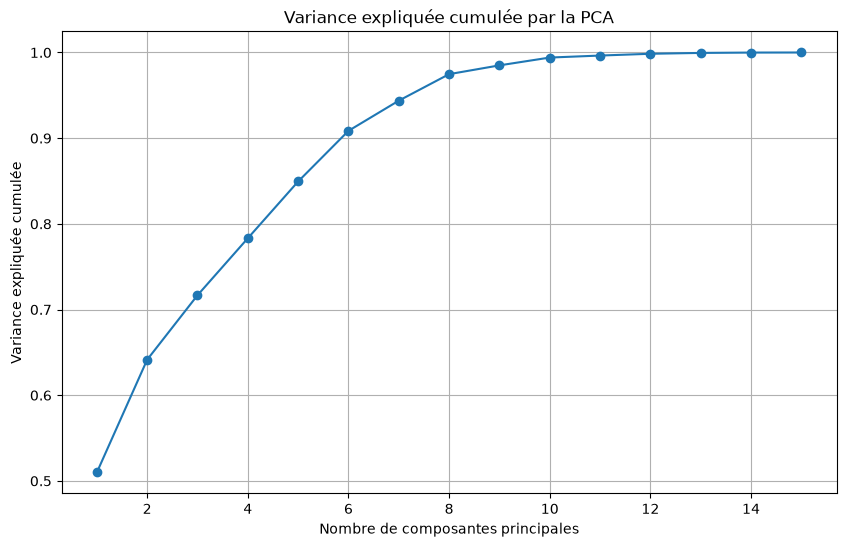

In [27]:
# Graphique de la variance
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Nombre de composantes principales")
plt.ylabel("Variance expliquée cumulée")
plt.title("Variance expliquée cumulée par la PCA")
plt.grid()
plt.show()

On remarque à travers le graphique que sur les 15 composantes, 8 suffisent à exprimer 95% de la variance et 10 suffisent à exprimer au moins 98% de la variance. Essayons l'ACP avec une variance à 95%

In [28]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(
    "Nombre de composantes nécessaires pour expliquer 95 % de la variance :",
    n_components_95
)

Nombre de composantes nécessaires pour expliquer 95 % de la variance : 8


In [29]:
pca_95 = PCA(n_components=n_components_95)

X_pca_95 = pca_95.fit_transform(X_scaled)

print("Dimension avant PCA :", X_scaled.shape)
print("Dimension après PCA :", X_pca_95.shape)

Dimension avant PCA : (1687861, 15)
Dimension après PCA : (1687861, 8)


## Rééchantillonnage des données déséquilibrées